In [1]:
from evaluation.FilterAgentEvaluator import FilterAgentEvaluator 
from no_tool_agent_runner import getFilterDeviceRunner


FOV_PATH = "../Evaluation/TestData/en/long/fov.json"
runner = getFilterDeviceRunner()

evaluator = FilterAgentEvaluator(FOV_PATH, runner)

SwitchBotOperator initialized with token: 24f7e6188be2361b2bcc2a165597d033b11c8a4f37feb8a194ce920a4fb7fce65bc70aa66f8f5a3800b7d0c890c4aa71 and secret: 52f782fb6bb3fe5ee46ddccbc7ba35e1
http://127.0.0.1:7070/device/operate
24f7e6188be2361b2bcc2a165597d033b11c8a4f37feb8a194ce920a4fb7fce65bc70aa66f8f5a3800b7d0c890c4aa71 52f782fb6bb3fe5ee46ddccbc7ba35e1
http://127.0.0.1:7070/device/operate
=== INIT START ===
ran_data initialized [{'id': '183e0e85-e669-40fc-b929-54cd123df122', 'ground_truth': {'filter_type': 'fov', 'params': {'isInFov': True, 'order': 'proximity', 'range': 2.0}}, 'predicted': {'filter_type': 'fov', 'params': {'isInFov': True, 'order': 'proximity', 'range': 2.0}}, 'metrics': {'tokens': {'prompt_tokens': 1182, 'completion_tokens': 44, 'total_tokens': 1226}, 'cost_usd': 0.000136, 'elapsed_seconds': 1.6242568492889404}, 'used_model': 'gpt-4.1-nano'}]
runner obtained
load_data done


In [ ]:
import multiprocessing
import os
from evaluation.FilterAgentEvaluator import FilterAgentEvaluator
from no_tool_agent_runner import getFilterDeviceRunner


def run_for_model(model_name: str, data_path: str, output_root: str):
    print(f"[{model_name}] 開始")
    runner = getFilterDeviceRunner()
    evaluator = FilterAgentEvaluator(data_path, runner)
    evaluator.change_model(model_name)

    evaluator.run_tests(0, 3)

    output_dir = os.path.join(output_root, model_name)
    evaluator.write_output_summary(output_dir)
    evaluator.write_type_summaries(output_dir)
    print(f"[{model_name}] 完了 ✅")






models = [
    "gpt-4.1-nano",
    "gpt-4o",
    "gpt-3.5-turbo",
    # 他にも追加可能
]

data_path = "../Evaluation/TestData/en/long/fov.json"
output_root = "../Evaluation/Result"

# 並列実行
with multiprocessing.Pool(processes=len(models)) as pool:
    pool.starmap(run_for_model, [(model, data_path, output_root) for model in models])

    


In [2]:
evaluator.analyzer.display_overview()

evaluator.write_output_summary("../Evaluation/Result")
evaluator.write_type_summaries("../Evaluation/Result")

| Task ID   | Prompt                                                          | Ground Truth   | Predicted   | ✅ Exact Match   | ✅ filter_type_match   | param_match                      |   Cost (USD) |   Response Time (s) | Model        |
|:----------|:----------------------------------------------------------------|:---------------|:------------|:-----------------|:-----------------------|:---------------------------------|-------------:|--------------------:|:-------------|
| FOV01     | Turn on all visible ones in my field of view within 2.0 meters. | fov            | fov         | ✅               | ✅                     | ✅ ['isInFov', 'order', 'range'] |     0.000136 |             1.62426 | gpt-4.1-nano |
✅ ran_data saved to: ../Evaluation/Result\summary\json\ran_data.json
📊 summary saved to: ../Evaluation/Result\summary\json\summary.json
| Task ID   | Prompt                                                          | Ground Truth   | Predicted   | ✅ Exact Match   | ✅ filter_type_

In [3]:
evaluator.change_model("gpt-4.1-nano")
evaluator.run_tests(0,len(evaluator.data))
evaluator.change_model("gpt-4.1")
evaluator.run_tests(0,len(evaluator.data))  
evaluator.change_model("gpt-4o")
evaluator.run_tests(0,len(evaluator.data))




[change_model] GPT_MODEL set to: gpt-4.1-nano
🚀 実行範囲: index 0 ～ 4
🔍 [0] 実行中: ID = 183e0e85-e669-40fc-b929-54cd123df122 🗨️「Turn on all visible ones in my field of view within 2.0 meters.」
   結果: ✅  filter_type: ✅ | isInFov: ✅, order: ✅, range: ✅
time_taken:  1.3943696022033691
cost_usd: $ 0.000137
🔍 [1] 実行中: ID = d4aa683d-a3a7-4c30-8519-b6b5a014256f 🗨️「Could you activate everything I can currently see?」
   結果: ✅  filter_type: ✅ | isInFov: ✅, order: ✅, range: ✅
time_taken:  1.0248587131500244
cost_usd: $ 0.000135
🔍 [2] 実行中: ID = dfcfcb7b-8313-43ae-bb3c-11101b9c4e4b 🗨️「Switch off any visible devices within 1.5 meters.」
   結果: ✅  filter_type: ✅ | isInFov: ✅, order: ✅, range: ✅
time_taken:  1.1133310794830322
cost_usd: $ 0.000137
🔍 [3] 実行中: ID = 0ab83626-de43-4565-a78d-c40d1f47d195 🗨️「Power on the rightmost light that’s visible to me.」
   結果: ✅  filter_type: ✅ | isInFov: ✅, order: ✅, range: ✅
time_taken:  0.960803747177124
cost_usd: $ 0.000135
🔍 [4] 実行中: ID = 989a6385-e4b6-4287-af6e-abffca0

[{'id': '183e0e85-e669-40fc-b929-54cd123df122',
  'ground_truth': {'filter_type': 'fov',
   'params': {'isInFov': True, 'order': 'proximity', 'range': 2.0}},
  'predicted': {'filter_type': 'fov',
   'params': {'isInFov': True, 'order': 'proximity', 'range': 2.0}},
  'metrics': {'tokens': {'prompt_tokens': 1182,
    'completion_tokens': 48,
    'total_tokens': 1230},
   'cost_usd': 0.000137,
   'elapsed_seconds': 1.3943696022033691},
  'used_model': 'gpt-4.1-nano'},
 {'id': 'd4aa683d-a3a7-4c30-8519-b6b5a014256f',
  'ground_truth': {'filter_type': 'fov',
   'params': {'isInFov': True, 'order': 'proximity', 'range': 0.0}},
  'predicted': {'filter_type': 'fov',
   'params': {'isInFov': True, 'order': 'proximity', 'range': 0.0}},
  'metrics': {'tokens': {'prompt_tokens': 1174,
    'completion_tokens': 44,
    'total_tokens': 1218},
   'cost_usd': 0.000135,
   'elapsed_seconds': 1.0248587131500244},
  'used_model': 'gpt-4.1-nano'},
 {'id': 'dfcfcb7b-8313-43ae-bb3c-11101b9c4e4b',
  'ground_tr

Accuracy:  1.0
ExactMatch:  1.0
partial_match:  1.0
cost_summary:  {'total': 0.0006760000000000001, 'average': 0.0001352, 'max': 0.000136}
time_summary:  {'total': 5.87498140335083, 'average': 1.174996280670166, 'max': 1.6242568492889404}
                  precision    recall  f1-score   support

             fov       1.00      1.00      1.00         5
       direction       0.00      0.00      0.00         0
around_furniture       0.00      0.00      0.00         0
             all       0.00      0.00      0.00         0

       micro avg       1.00      1.00      1.00         5
       macro avg       0.25      0.25      0.25         5
    weighted avg       1.00      1.00      1.00         5

Confusion Matrix:
|                  |   fov |   direction |   around_furniture |   all |
|:-----------------|------:|------------:|-------------------:|------:|
| fov              |     5 |           0 |                  0 |     0 |
| direction        |     0 |           0 |                  

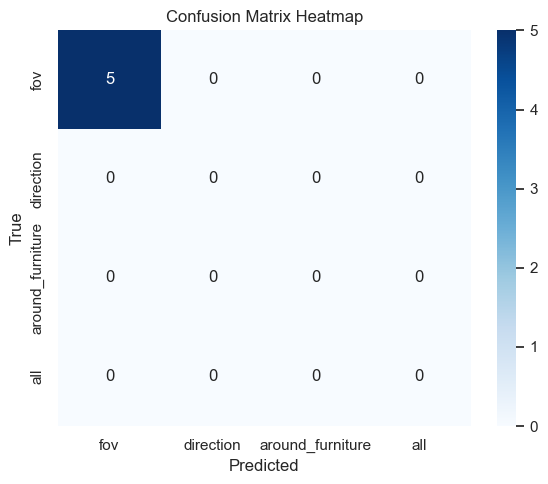

| Task ID   | Prompt                                                          | Ground Truth   | Predicted   | ✅ Exact Match   | ✅ filter_type_match   | param_match                      |   Cost (USD) |   Response Time (s) | Model        |
|:----------|:----------------------------------------------------------------|:---------------|:------------|:-----------------|:-----------------------|:---------------------------------|-------------:|--------------------:|:-------------|
| FOV01     | Turn on all visible ones in my field of view within 2.0 meters. | fov            | fov         | ✅               | ✅                     | ✅ ['isInFov', 'order', 'range'] |     0.000136 |             1.62426 | gpt-4.1-nano |
| FOV02     | Could you activate everything I can currently see?              | fov            | fov         | ✅               | ✅                     | ✅ ['isInFov', 'order', 'range'] |     0.000135 |             1.00331 | gpt-4.1-nano |
| FOV03     | Switch off any visible dev

In [5]:

results = evaluator.analyzer.evaluate_all(labels=["fov", "direction", "around_furniture", "all"])
print("Accuracy: ", results["type_accuracy"])
print("ExactMatch: ", results["exact_match_accuracy"])
print("partial_match: ", results["partial_match"])
print("cost_summary: ", results["cost_summary"])
print("time_summary: ", evaluator.analyzer.time_summary())
print(results["classification_report"])
evaluator.analyzer.plot_confusion_matrix(labels=["fov", "direction", "around_furniture", "all"])
df = evaluator.analyzer.display_overview()


### 🔎 分類精度
| Metric                          | Value   |
|:--------------------------------|:--------|
| Type Accuracy                   | 100.00% |
| Exact Match Accuracy            | 100.00% |
| Partial Match (filter_type一致) | 100.00% |

### 📐 パラメータ別詳細スコア
| Parameter   | Metric    |   Value |
|:------------|:----------|--------:|
| isInFov     | Precision |       1 |
| isInFov     | Recall    |       1 |
| isInFov     | F1        |       1 |
| order       | Precision |       1 |
| order       | Recall    |       1 |
| order       | F1        |       1 |
| range       | MAE       |       0 |


c:\Users\Tenma\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:386: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


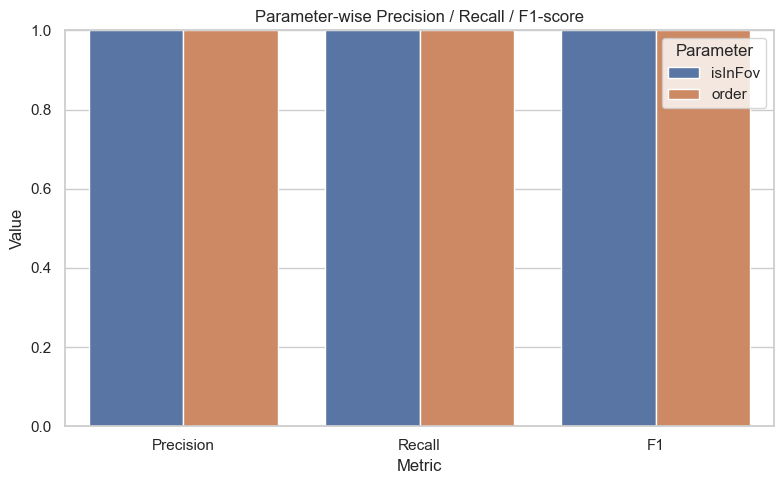

Range MAE (Mean Absolute Error): 0.00 m


In [6]:
import pandas as pd
# 🔹 FOVアナライザを取得
fov_analyzer = evaluator.type_analyzer("fov")

# 🔹 分類精度（完全一致 / filter_type一致）の表示
results = fov_analyzer.evaluate_all(labels=["fov"])
df_match = pd.DataFrame([
    {"Metric": "Type Accuracy ", "Value": f"{results['type_accuracy']:.2%}"},
    {"Metric": "Exact Match Accuracy", "Value": f"{results['exact_match_accuracy']:.2%}"},
    {"Metric": "Partial Match (filter_type一致)", "Value": f"{results['partial_match']:.2%}"}
])
print("### 🔎 分類精度")
print(df_match.to_markdown(index=False))

# 🔹 パラメータ分類精度のテーブル出力（Precision / Recall / F1 / MAE）
print("\n### 📐 パラメータ別詳細スコア")
fov_analyzer.show_param_metric_table()

# 🔹 パラメータごとの精度可視化（グラフ）
fov_analyzer.plot_param_metrics()


In [7]:
RESULT_PATH = "../Evaluation/Result"
evaluator.write_output_summary(RESULT_PATH)


✅ ran_data saved to: ../Evaluation/Result\json\ran_data.json
